# One Dot, Two Thousand People
## Mapping educational backlog as structural inequality in Mexico

**Application exercise 2 — Mapping inequality**
Samuel Dávila · Oscar Baltazar

---

### What this notebook does

It builds a **dot-density map** of *rezago educativo* (educational backlog) in Mexico from official
INEA estimates dated 31 December 2025, and exports it as a print-ready A2 poster.

A dot-density map was chosen over a choropleth for one reason: **a choropleth can only show a rate,
and the rate hides where the people are.** Chiapas has the worst rate in the country (44.9%), but the
State of Mexico has almost twice as many people in backlog. Mexico City has the *best* rate in the
country (16.6%) and still contains more people in backlog than the whole of Guerrero. A rate map tells
you one of those facts; a dot map tells you both at once, because **density encodes volume and colour
encodes depth**.

### Encoding summary

| Visual channel | Variable | Why |
|---|---|---|
| Dot **density** | absolute people in backlog | volume — where the people actually are |
| Dot **colour** | type of backlog (illiterate / no primary / no secondary) | depth — how far behind |
| **Projection** | Albers Equal-Area Conic | equal ink must mean equal ground, or density lies |
| Ranked **stacked bars** | % of adults in backlog, by state | restores the rate the map alone would hide |

## 1 · Setup

In [1]:
import json, unicodedata
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.path import Path as MPath
from matplotlib.patches import PathPatch
import matplotlib.patches as mpatches

RNG = np.random.default_rng(42)   # fixed seed -> the poster is reproducible
PEOPLE_PER_DOT = 2000

DATA = "../data"
OUT  = "../output"

## 2 · Load the INEA estimates

The source file is the official workbook published by INEA's *Dirección de Prospectiva, Acreditación y
Evaluación*. It is a formatted report, not a tidy table: the real header sits on row 8, the national
row on row 10, and each indicator is followed by two *Lugar* (rank) columns. We select columns by
position and keep only the 32 states.

The indicator is decomposed into three nested, mutually exclusive levels of deprivation:

- **Analfabetas** — cannot read or write
- **Sin primaria terminada** — literate, but primary school incomplete
- **Sin secundaria terminada** — primary done, lower-secondary incomplete

Their sum is *Rezago total*. This decomposition is what lets a single dot carry two variables.

In [2]:
raw = pd.read_excel(f"{DATA}/est_rez_ent_2025.xlsx", header=None)

# cols: 1 name | 2 pop15+ | 3 illiterate | 5 % | 7 no-primary | 9 % | 11 no-secondary | 13 % | 15 total | 17 %
df = raw.iloc[11:43, [1, 2, 3, 5, 7, 9, 11, 13, 15, 17]].copy()
df.columns = ["estado", "pob15", "analf", "analf_pct", "sin_prim", "sin_prim_pct",
              "sin_sec", "sin_sec_pct", "rezago", "rezago_pct"]
for c in df.columns[1:]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.reset_index(drop=True)

df.head()

,estado,pob15,analf,analf_pct,sin_prim,sin_prim_pct,sin_sec,sin_sec_pct,rezago,rezago_pct
0,Aguascalientes,1166245,18285,1.6,63260,5.4,157427,13.5,238972,20.5
1,Baja California,3278272,51001,1.6,174104,5.3,471550,14.4,696655,21.3
2,Baja California Sur,704817,13904,2.0,38262,5.4,90633,12.9,142799,20.3
3,Campeche,733293,36261,4.9,59813,8.2,96540,13.2,192614,26.3
4,Coahuila de Zaragoza,2577081,30572,1.2,73616,2.9,351294,13.6,455482,17.7


### 2.1 · Validation

Two independent checks before anything is drawn. If either fails, the columns were misread.

In [3]:
assert len(df) == 32, f"expected 32 states, got {len(df)}"
assert df.isna().sum().sum() == 0, "missing values in the parsed table"

# (a) components must sum to the reported total, state by state
comp = df.analf + df.sin_prim + df.sin_sec
assert (comp == df.rezago).all(), "components do not sum to the reported total"

# (b) our national rate must reproduce the published 26.6 %
national_rate = df.rezago.sum() / df.pob15.sum() * 100
print(f"people in educational backlog : {df.rezago.sum():,}")
print(f"adults aged 15+               : {df.pob15.sum():,}")
print(f"national rate (computed)      : {national_rate:.1f}%   (INEA publishes 26.6%)")
assert round(national_rate, 1) == 26.6
print("\nBoth checks passed.")

people in educational backlog : 27,233,798
adults aged 15+               : 102,329,771
national rate (computed)      : 26.6%   (INEA publishes 26.6%)

Both checks passed.


## 3 · The argument, before the picture

The whole point of the map is the gap between these two rankings. If they agreed, a plain choropleth
would be enough and this exercise would be uninteresting.

In [4]:
SHORT = {"Veracruz de Ignacio de la Llave": "Veracruz", "Michoacán de Ocampo": "Michoacán",
         "Coahuila de Zaragoza": "Coahuila", "México": "Estado de México",
         "Ciudad de México": "Mexico City"}
df["label"] = df.estado.map(lambda s: SHORT.get(s, s))

by_rate = df.nlargest(5, "rezago_pct")[["label", "rezago_pct", "rezago"]]
by_vol  = df.nlargest(5, "rezago")[["label", "rezago", "rezago_pct"]]

print("TOP 5 BY RATE                      TOP 5 BY VOLUME")
for (_, a), (_, b) in zip(by_rate.iterrows(), by_vol.iterrows()):
    print(f"{a.label:<20}{a.rezago_pct:>5.1f}%      {b.label:<20}{b.rezago/1e6:>5.2f}M")

TOP 5 BY RATE                      TOP 5 BY VOLUME
Chiapas              44.9%      Estado de México     3.25M
Michoacán            40.0%      Veracruz             2.32M
Guerrero             39.3%      Chiapas              1.88M
Oaxaca               37.3%      Jalisco              1.85M
Veracruz             36.7%      Puebla               1.75M


In [5]:
# depth of the backlog: what share of it is outright illiteracy?
df["share_analf"] = df.analf / df.rezago * 100
deep = df.nlargest(3, "share_analf")[["label", "share_analf"]]
shallow = df.nsmallest(3, "share_analf")[["label", "share_analf"]]
print("Illiteracy as a share of each state's backlog\n")
print("deepest :", ", ".join(f"{r.label} {r.share_analf:.1f}%" for _, r in deep.iterrows()))
print("shallowest:", ", ".join(f"{r.label} {r.share_analf:.1f}%" for _, r in shallow.iterrows()))

Illiteracy as a share of each state's backlog

deepest : Guerrero 26.0%, Oaxaca 25.3%, Hidalgo 20.8%
shallowest: Coahuila 6.7%, Sonora 7.0%, Baja California 7.3%


**Reading.** The south is not merely further behind, it is further *down*: in Guerrero one quarter of
the people in backlog cannot read or write at all, against roughly one in fifteen in Coahuila. Two
states can share a backlog rate and mean very different things by it — which is exactly why colour
carries the composition.

## 4 · Geometry

State boundaries come from a public GeoJSON of Mexico's 32 federal entities. Names are normalised
(accents stripped, historical names mapped) so that every INEA row matches exactly one polygon — a
silent mismatch here would quietly delete a state's population from the map, so we assert on it.

In [6]:
def norm(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode()
    return s.lower().strip()

ALIAS = {"veracruz de ignacio de la llave": "veracruz",
         "michoacan de ocampo": "michoacan",
         "coahuila de zaragoza": "coahuila",
         "ciudad de mexico": "distrito federal"}
GALIAS = {**ALIAS, "queretaro de arteaga": "queretaro", "estado de mexico": "mexico"}

df["key"] = df.estado.map(lambda s: ALIAS.get(norm(s), norm(s)))

gj = json.load(open(f"{DATA}/mx.json"))
feats = {}
for f in gj["features"]:
    k = norm(f["properties"]["name"])
    feats[GALIAS.get(k, k)] = f

assert set(df.key) == set(feats), (
    f"unmatched -> data:{set(df.key)-set(feats)}  geo:{set(feats)-set(df.key)}")
print(f"{len(feats)} states matched to polygons — no gaps.")

32 states matched to polygons — no gaps.


### 4.1 · Projection: Albers Equal-Area Conic

This choice is not decoration. **A dot-density map is a statement about area.** If the projection
stretches the north relative to the south — as Web Mercator does — then identical dot counts spread
over visually different areas, and the reader mis-reads density as a data signal when it is a
projection artefact.

The Albers Equal-Area Conic preserves area exactly. We implement it directly with standard parallels
at 14.5°N and 32.5°N, which bracket Mexico:

$$n=\frac{\sin\varphi_1+\sin\varphi_2}{2},\qquad
C=\cos^2\varphi_1+2n\sin\varphi_1,\qquad
\rho=\frac{\sqrt{C-2n\sin\varphi}}{n}$$

$$x=\rho\sin\!\big(n(\lambda-\lambda_0)\big),\qquad
y=\rho_0-\rho\cos\!\big(n(\lambda-\lambda_0)\big)$$

In [7]:
PHI0, LAM0 = np.radians(23.0), np.radians(-102.0)     # origin
PHI1, PHI2 = np.radians(14.5), np.radians(32.5)       # standard parallels

_n    = (np.sin(PHI1) + np.sin(PHI2)) / 2.0
_C    = np.cos(PHI1) ** 2 + 2 * _n * np.sin(PHI1)
_rho0 = np.sqrt(_C - 2 * _n * np.sin(PHI0)) / _n

def project(lon, lat):
    lon = np.radians(np.asarray(lon, float))
    lat = np.radians(np.asarray(lat, float))
    theta = _n * (lon - LAM0)
    rho = np.sqrt(np.clip(_C - 2 * _n * np.sin(lat), 0, None)) / _n
    return rho * np.sin(theta), _rho0 - rho * np.cos(theta)

def rings(feature):
    '''Project a (Multi)Polygon into [(exterior, [holes]), ...] in plane coords.'''
    g = feature["geometry"]
    polys = g["coordinates"] if g["type"] == "MultiPolygon" else [g["coordinates"]]
    out = []
    for poly in polys:
        def P(ring):
            r = np.array(ring, float)
            x, y = project(r[:, 0], r[:, 1])
            return np.column_stack([x, y])
        out.append((P(poly[0]), [P(h) for h in poly[1:]]))
    return out

state_paths = {k: rings(f) for k, f in feats.items()}
print("projected", len(state_paths), "states")

projected 32 states


## 5 · Placing the dots

Each dot stands for 2,000 people. For a state we draw `round(value / 2000)` points **uniformly at
random inside its polygon**, by rejection sampling against the bounding box, subtracting holes, and
allocating across multi-part geometries in proportion to their true (projected) area.

Because the projection is equal-area, uniform sampling in the plane is uniform on the ground.

> **Important caveat, and it is printed on the poster.** Dot position is random *within* the state.
> It says nothing about where individuals live. The honest claim a dot map makes is about **how many**
> and **what kind**, aggregated to the state — not about location inside it.

In [8]:
def polygon_area(p):
    x, y = p[:, 0], p[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

def sample_points(parts, n):
    if n <= 0:
        return np.empty((0, 2))
    areas = np.array([max(polygon_area(e) - sum(polygon_area(h) for h in hs), 1e-12)
                      for e, hs in parts])
    alloc = RNG.multinomial(n, areas / areas.sum())      # area-weighted across islands
    chunks = []
    for (ext, holes), k in zip(parts, alloc):
        if k == 0:
            continue
        ep, hps = MPath(ext), [MPath(h) for h in holes]
        (x0, y0), (x1, y1) = ext.min(axis=0), ext.max(axis=0)
        need, tries = k, 0
        while need > 0 and tries < 200:
            batch = max(int(need * 3), 64)
            cand = np.column_stack([RNG.uniform(x0, x1, batch), RNG.uniform(y0, y1, batch)])
            inside = ep.contains_points(cand)
            for hp in hps:
                inside &= ~hp.contains_points(cand)
            ok = cand[inside][:need]
            if len(ok):
                chunks.append(ok); need -= len(ok)
            tries += 1
    return np.vstack(chunks) if chunks else np.empty((0, 2))

dots = {}
for _, row in df.iterrows():
    dots[row.key] = {
        "analf":    sample_points(state_paths[row.key], int(round(row.analf    / PEOPLE_PER_DOT))),
        "sin_prim": sample_points(state_paths[row.key], int(round(row.sin_prim / PEOPLE_PER_DOT))),
        "sin_sec":  sample_points(state_paths[row.key], int(round(row.sin_sec  / PEOPLE_PER_DOT))),
    }

N_DOTS = sum(len(v) for s in dots.values() for v in s.values())
print(f"{N_DOTS:,} dots  ·  1 dot = {PEOPLE_PER_DOT:,} people  ·  represents {N_DOTS*PEOPLE_PER_DOT:,}")

13,618 dots  ·  1 dot = 2,000 people  ·  represents 27,236,000


## 6 · Colour

Three ordered categories, so the ramp runs dark → light with severity: **violet** (illiterate) →
**red** (no primary) → **amber** (no lower secondary).

The palette was checked against colour-vision-deficiency separation rather than chosen by eye. On the
all-pairs test — the right test here, because on a dot map any two colours can end up adjacent — the
worst pair scores ΔE 15.3 under deuteranopia (target ≥ 8) and ΔE 20.8 for normal vision (floor ≥ 15).
Amber falls below 3:1 contrast against the paper, so the poster carries the **relief** the rule
requires: a labelled legend and the full ranked table of values, so no reading depends on colour alone.

In [9]:
C_ANALF, C_PRIM, C_SEC = "#4a3aa7", "#e34948", "#eda100"
BG, INK, INK2, INK3, OUTLINE = "#fbf7f0", "#141414", "#55514a", "#8a8479", "#b9b2a5"

fig, ax = plt.subplots(figsize=(7, 1.1), dpi=110)
for i, (c, n) in enumerate([(C_ANALF, "Illiterate"), (C_PRIM, "No primary"), (C_SEC, "No secondary")]):
    ax.add_patch(mpatches.Rectangle((i, 0), .9, 1, color=c))
    ax.text(i + .45, -.28, n, ha="center", fontsize=9, color=INK)
    ax.text(i + .45, .5, c, ha="center", va="center", fontsize=8.5, color="white", weight="bold")
ax.set_xlim(-.05, 3); ax.set_ylim(-.5, 1.05); ax.axis("off")
fig.patch.set_facecolor(BG); plt.show()

## 7 · Composing the A2 poster

A2 portrait is 42 × 59.4 cm = 16.54 × 23.39 in. At 300 dpi that is 4960 × 7016 px. The layout is four
bands: title, legend, map, ranked bars, footer.
This part was made by assitance of Claude AI, we couldn't figure it out a way to make it look fancy as good as we want.

In [10]:
FIG_W, FIG_H = 16.535, 23.386
fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=300)
fig.patch.set_facecolor(BG)

# ---------------------------------------------------------------- map
ax_map = fig.add_axes([0.045, 0.345, 0.91, 0.425]); ax_map.set_facecolor(BG); ax_map.set_axis_off()

for parts in state_paths.values():
    for ext, holes in parts:
        verts, codes = [], []
        for r in [ext] + holes:
            codes += [MPath.MOVETO] + [MPath.LINETO] * (len(r) - 1)
            verts.append(r)
        ax_map.add_patch(PathPatch(MPath(np.vstack(verts), codes),
                                   facecolor="#ffffff", edgecolor=OUTLINE, lw=0.7, zorder=1))

for key, d in dots.items():
    for k, col, z in (("sin_sec", C_SEC, 2), ("sin_prim", C_PRIM, 3), ("analf", C_ANALF, 4)):
        p = d[k]
        if len(p):
            ax_map.scatter(p[:, 0], p[:, 1], s=2.1, c=col, linewidths=0, alpha=0.85, zorder=z)

allv = np.vstack([e for parts in state_paths.values() for e, _ in parts])
ax_map.set_xlim(allv[:, 0].min() - .02, allv[:, 0].max() + .02)
ax_map.set_ylim(allv[:, 1].min() - .02, allv[:, 1].max() + .02)
ax_map.set_aspect("equal")

def centroid(key):
    return max(state_paths[key], key=lambda p: polygon_area(p[0]))[0].mean(axis=0)

CALLOUTS = [
    ("mexico", "ESTADO DE MÉXICO\n3,249,316 people — the largest absolute\nbacklog in the country, yet only 23.5% of\nits adults (rank 21 of 32 by rate).", (0.015, 0.63), "left"),
    ("distrito federal", "MEXICO CITY\nThe lowest rate in Mexico (16.6%)\nand still 1,283,013 people —\nmore than all of Guerrero (39.3%).", (0.985, 0.72), "right"),
    ("guerrero", "GUERRERO\n26% of its backlog is people who cannot\nread or write. In Coahuila that share is\n6.7%. The south is not only further\nbehind — it is further down.", (0.015, 0.15), "left"),
    ("chiapas", "CHIAPAS\n44.9% — nearly one in two adults.\nThe deepest backlog in Mexico.", (0.985, 0.09), "right"),
]
for key, txt, xy, ha in CALLOUTS:
    ax_map.annotate(txt, xy=centroid(key), xycoords="data", xytext=xy, textcoords="axes fraction",
                    ha=ha, va="center", fontsize=9.2, color=INK, linespacing=1.55, zorder=10,
                    bbox=dict(boxstyle="round,pad=0.5", fc="#ffffff", ec=OUTLINE, lw=0.8, alpha=0.97),
                    arrowprops=dict(arrowstyle="-", color=INK2, lw=0.9,
                                    connectionstyle="arc3,rad=0.10", shrinkA=6, shrinkB=4))

# ---------------------------------------------------------------- title
fig.text(0.035, 0.955, "ONE DOT, TWO THOUSAND PEOPLE", fontsize=13, color=C_PRIM, weight="bold")
fig.text(0.035, 0.925, "The Geography of Educational Backlog in Mexico",
         fontsize=34, color=INK, weight="bold", va="top")
fig.text(0.035, 0.885,
         f"{df.rezago.sum():,} people aged 15 and over — {national_rate:.1f}% of Mexico's adult population — have not completed basic education.\n"
         f"Every dot below is {PEOPLE_PER_DOT:,} of them, placed at random inside their own state. Colour shows how deep the deprivation runs.",
         fontsize=11.5, color=INK2, va="top", linespacing=1.6)

# ---------------------------------------------------------------- legend
ax_l = fig.add_axes([0.035, 0.782, 0.93, 0.085]); ax_l.set_axis_off()
ax_l.set_xlim(0, 1); ax_l.set_ylim(0, 1)
ax_l.add_patch(mpatches.FancyBboxPatch((0.002, 0.02), 0.996, 0.96, boxstyle="round,pad=0.004",
                                       fc="#ffffff", ec=OUTLINE, lw=0.8))
items = [(C_ANALF, "Illiterate", "cannot read or write", df.analf.sum(), df.analf.sum()/df.pob15.sum()*100),
         (C_PRIM, "No primary school", "literate, primary incomplete", df.sin_prim.sum(), df.sin_prim.sum()/df.pob15.sum()*100),
         (C_SEC, "No lower secondary", "primary done, secondary incomplete", df.sin_sec.sum(), df.sin_sec.sum()/df.pob15.sum()*100)]
gx, gy = np.meshgrid(np.arange(3), np.arange(3))
for i, (col, name, sub, val, pct) in enumerate(items):
    x = 0.035 + i * 0.245
    ax_l.scatter(x + 0.006 + gx.ravel() * 0.0115, 0.70 - gy.ravel() * 0.20, s=26, c=col, lw=0, zorder=5)
    ax_l.text(x + 0.05, 0.74, name, fontsize=12, color=INK, weight="bold", va="center")
    ax_l.text(x + 0.05, 0.53, sub, fontsize=8.8, color=INK3, va="center")
    ax_l.text(x + 0.05, 0.28, f"{val:,}  ·  {pct:.1f}% of adults", fontsize=9.6, color=INK2, va="center")
ax_l.plot([0.78, 0.78], [0.12, 0.88], color=OUTLINE, lw=0.8)
ax_l.text(0.80, 0.74, f"1 dot = {PEOPLE_PER_DOT:,} people", fontsize=12, color=INK, weight="bold", va="center")
ax_l.text(0.80, 0.53, f"{N_DOTS:,} dots on this map", fontsize=8.8, color=INK3, va="center")
ax_l.text(0.80, 0.28, "Albers equal-area projection:\nequal ink = equal ground",
          fontsize=8.6, color=INK2, va="center", linespacing=1.5)

# ---------------------------------------------------------------- ranked bars
ax_b = fig.add_axes([0.115, 0.072, 0.845, 0.225]); ax_b.set_facecolor(BG)
d = df.sort_values("rezago_pct").reset_index(drop=True)
y = np.arange(len(d))
ax_b.barh(y, d.analf_pct, height=.62, color=C_ANALF, zorder=3)
ax_b.barh(y, d.sin_prim_pct, left=d.analf_pct, height=.62, color=C_PRIM, zorder=3)
ax_b.barh(y, d.sin_sec_pct, left=d.analf_pct + d.sin_prim_pct, height=.62, color=C_SEC, zorder=3)
ax_b.set_yticks(y); ax_b.set_yticklabels(d.label, fontsize=8.6, color=INK)
ax_b.set_ylim(-.8, len(d) - .2); ax_b.set_xlim(0, 48)
for i, (p, n) in enumerate(zip(d.rezago_pct, d.rezago)):
    ax_b.text(p + .7, i, f"{p:.1f}%   ({n/1e6:.2f}M)", va="center", fontsize=8.2, color=INK2, zorder=6,
              bbox=dict(boxstyle="square,pad=0.12", fc=BG, ec="none"))
ax_b.axvline(national_rate, color=INK, lw=1.1, ls=(0, (4, 3)), zorder=5)
ax_b.text(national_rate, len(d) - .1, f"National average  {national_rate:.1f}%", fontsize=9.5,
          color=INK, weight="bold", va="bottom", ha="center")
for s in ("top", "right", "left"):
    ax_b.spines[s].set_visible(False)
ax_b.spines["bottom"].set_color(OUTLINE)
ax_b.tick_params(axis="x", colors=INK3, labelsize=8.5, length=3)
ax_b.tick_params(axis="y", length=0)
ax_b.set_xlabel("% of population aged 15+ in educational backlog", fontsize=9.5, color=INK2, labelpad=6)
ax_b.grid(axis="x", color="#e4ded2", lw=.7, zorder=0); ax_b.set_axisbelow(True)
fig.text(0.035, 0.313, "RATE VS. VOLUME — every state, ranked by rate", fontsize=13, color=INK, weight="bold")

# ---------------------------------------------------------------- footer
fig.text(0.965, 0.052, "Samuel Dávila  ·  Oscar Baltazar", fontsize=9.5, color=INK, ha="right", weight="bold")
fig.text(0.035, 0.040, "Educational backlog (rezago educativo): population aged 15 and over that has not completed "
                       "lower-secondary education. Estimates as of 31 December 2025.", fontsize=8.6, color=INK2)
fig.text(0.035, 0.026, "Source: Instituto Nacional para la Educación de los Adultos (INEA) — “Estimación del rezago educativo "
                       "al 31 de diciembre de 2025 por entidad federativa”. gob.mx/inea", fontsize=8.6, color=INK2)
fig.text(0.035, 0.012, "Boundaries: OpenStreetMap contributors.  Dot placement is random within each state and does not indicate "
                       "where individuals live.", fontsize=8.0, color=INK3)

print("composed")

composed


## 8 · Export

Two files. The **PDF is the one to print** — its vectors stay sharp at A2 and the printer can scale it
without resampling. The PNG is the Canvas upload.

In [11]:
import os
os.makedirs(OUT, exist_ok=True)
fig.savefig(f"{OUT}/rezago_dotmap_A2.pdf", facecolor=BG)
fig.savefig(f"{OUT}/rezago_dotmap_A2.png", dpi=300, facecolor=BG)
df.drop(columns="key").to_csv(f"{OUT}/rezago_educativo_2025_tidy.csv", index=False)

for f in sorted(os.listdir(OUT)):
    size_mb = os.path.getsize(os.path.join(OUT, f)) / 1e6
    print(f"{f:<36}{size_mb:>8.2f} MB")

rezago_dotmap_A2.pdf                    0.39 MB
rezago_dotmap_A2.png                    2.55 MB
rezago_educativo_2025_tidy.csv          0.00 MB


A2 poster · 4960 × 7015 px at 300 dpi


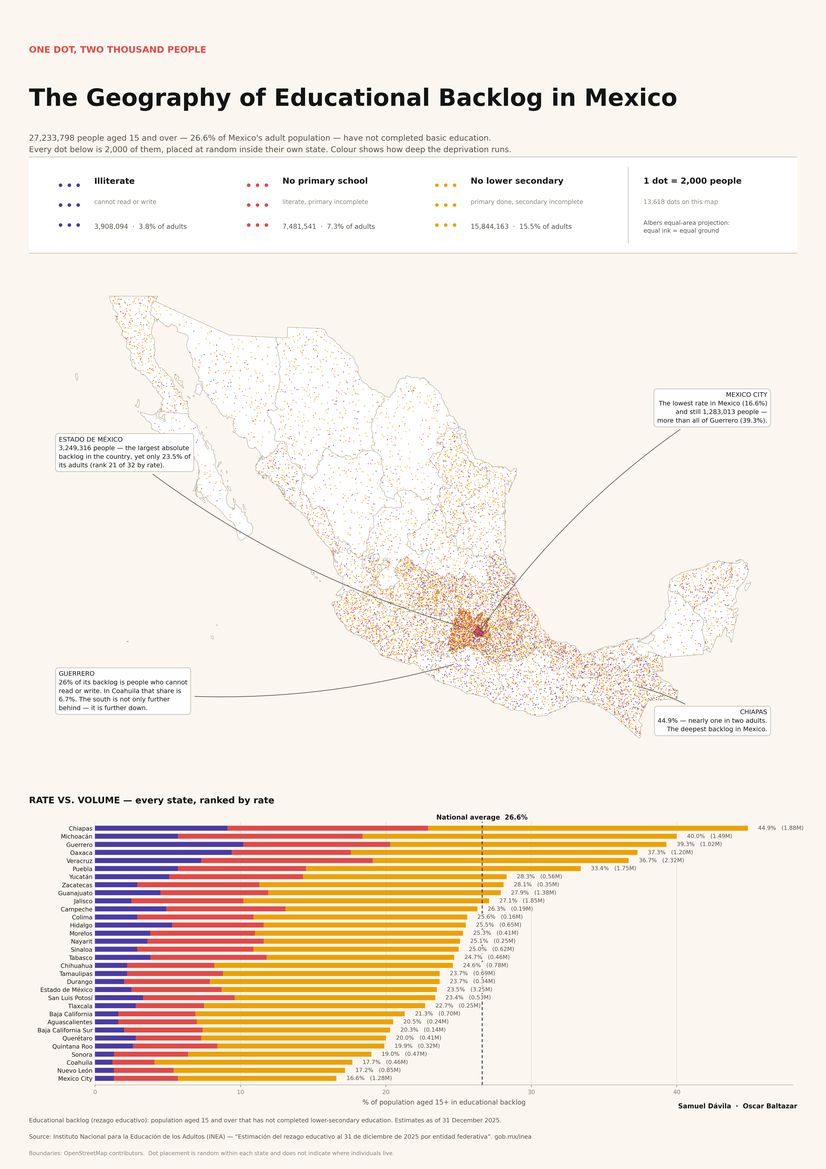

In [12]:
from IPython.display import Image, display
from PIL import Image as PILImage
im = PILImage.open(f"{OUT}/rezago_dotmap_A2.png")
im.resize((im.width // 6, im.height // 6), PILImage.LANCZOS).save(f"{OUT}/preview.png")
print(f"A2 poster · {im.width} × {im.height} px at 300 dpi")
display(Image(f"{OUT}/preview.png"))

## 9 · Reference

Instituto Nacional para la Educación de los Adultos (INEA), Dirección de Prospectiva, Acreditación y
Evaluación. *Estimación de la población de 15 años y más en rezago educativo por entidad federativa,
al 31 de diciembre de 2025.*
https://www.gob.mx/inea/documentos/estimaciones-del-rezago-educativo-al-31-de-diciembre-de-2025

Boundary geometry: OpenStreetMap contributors, via a public GeoJSON of Mexico's federal entities.